In [ ]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
shap.initjs()   # enables interactive SHAP plots in notebook

# ── Path Setup (notebook lives in notebooks/, run from there) ─
BASE_DIR   = os.path.join(os.getcwd(), '..')  
DATA_DIR   = os.path.join(BASE_DIR, 'data')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
PLOTS_DIR  = os.path.join(BASE_DIR, 'plots')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

RAW_CSV     = os.path.join(DATA_DIR,   'data.csv')
CLEANED_CSV = os.path.join(DATA_DIR,   'Data_Cleaned.csv')
MODEL_PKL   = os.path.join(MODELS_DIR, 'xgb_model.pkl')

print('✅ Paths configured')
print(f'   Data    → {DATA_DIR}')
print(f'   Models  → {MODELS_DIR}')
print(f'   Plots   → {PLOTS_DIR}')

C:\Users\KAVINI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Paths configured
   Data    → d:\Education\Academic\ML Assignment\notebooks\..\data
   Models  → d:\Education\Academic\ML Assignment\notebooks\..\models
   Plots   → d:\Education\Academic\ML Assignment\notebooks\..\plots


In [2]:
df = pd.read_csv(RAW_CSV)

print('=' * 55)
print('DATASET OVERVIEW')
print('=' * 55)
print(f'Shape         : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Years covered : {sorted(df["Year"].unique())}')
print(f'Districts     : {df["District"].nunique()}')
print(f'Provinces     : {df["Province"].nunique()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(10)

DATASET OVERVIEW
Shape         : 900 rows × 11 columns
Years covered : [np.int64(2019), np.int64(2020), np.int64(2021)]
Districts     : 25
Provinces     : 9

Missing values:
Year                 0
Province             0
District             0
Latitude             0
Longitude            0
Elevation            0
Month                0
Cases                0
Temp_avg             1
Precipitation_avg    1
Humidity_avg         1
dtype: int64


,Year,Province,District,Latitude,Longitude,Elevation,Month,Cases,Temp_avg,Precipitation_avg,Humidity_avg
0,2019,Western,Colombo,6.924429,79.907250,4,1,1225,26.914286,0.771429,72.607143
1,2019,Western,Gampaha,7.065026,79.966220,19,1,724,27.417857,0.728571,69.892857
2,2019,Western,Kalutara,6.572935,80.025190,5,1,372,26.112500,1.396429,80.464286
3,2019,Central,Kandy,7.275923,80.626590,499,1,288,22.067857,1.853571,83.428571
4,2019,Central,Matale,7.486819,80.526320,362,1,62,25.592857,0.850000,74.285714
5,2019,Central,Nuwara Eliya,6.994728,80.734180,1865,1,26,14.741071,2.717857,86.571429
6,2019,Southern,Galle,6.080843,80.233730,8,1,132,25.432143,2.953571,85.285714
7,2019,Southern,Hambantota,5.940246,80.550000,6,1,140,25.760714,0.828571,83.357143
8,2019,Southern,Matara,6.151143,81.127815,8,1,219,27.287500,0.710714,71.000000
9,2019,Northern,Jaffna,9.666080,80.034874,8,1,900,25.105357,0.178571,74.892857


In [3]:
df.describe().round(2)

,Year,Latitude,Longitude,Elevation,Month,Cases,Temp_avg,Precipitation_avg,Humidity_avg
count,900.00,900.00,900.00,900.00,900.00,900.00,899.00,899.00,899.00
mean,2020.00,7.59,80.59,173.20,6.50,190.26,26.64,5.30,80.40
std,0.82,1.03,0.52,383.13,3.45,407.36,2.97,4.64,6.78
min,2019.00,5.94,79.85,4.00,1.00,0.00,14.73,0.09,60.36
25%,2019.00,6.92,80.23,8.00,3.75,13.00,25.87,1.63,75.59
50%,2020.00,7.28,80.53,19.00,6.50,51.00,26.89,3.88,81.82
75%,2021.00,8.33,81.02,129.00,9.25,164.25,28.45,7.71,85.66
max,2021.00,9.67,81.69,1865.00,12.00,4217.00,31.78,25.18,94.36


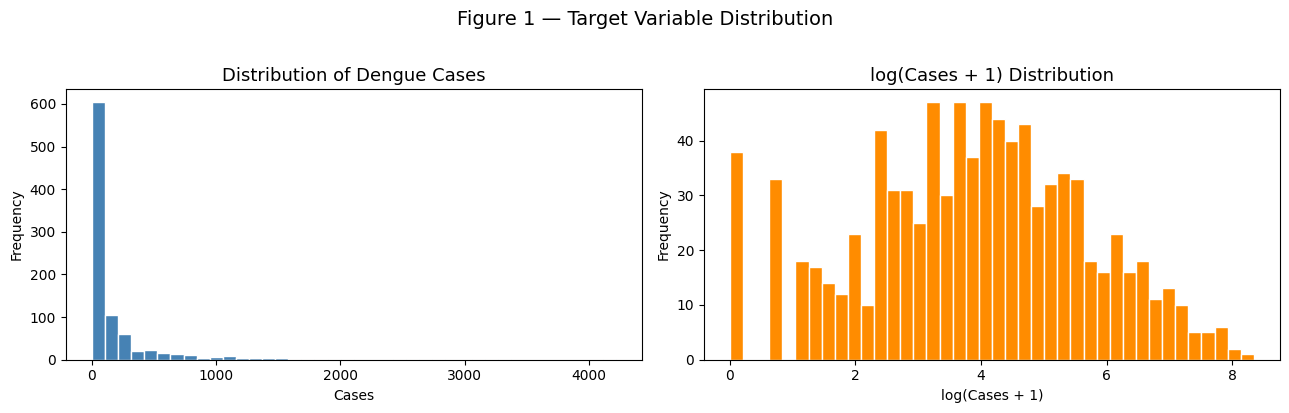

💾 Saved → plots/fig01_case_distribution.png


In [4]:
# ── EDA Plot 1: Case Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Cases'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Dengue Cases', fontsize=13)
axes[0].set_xlabel('Cases'); axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Cases']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('log(Cases + 1) Distribution', fontsize=13)
axes[1].set_xlabel('log(Cases + 1)'); axes[1].set_ylabel('Frequency')

plt.suptitle('Figure 1 — Target Variable Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig01_case_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig01_case_distribution.png')

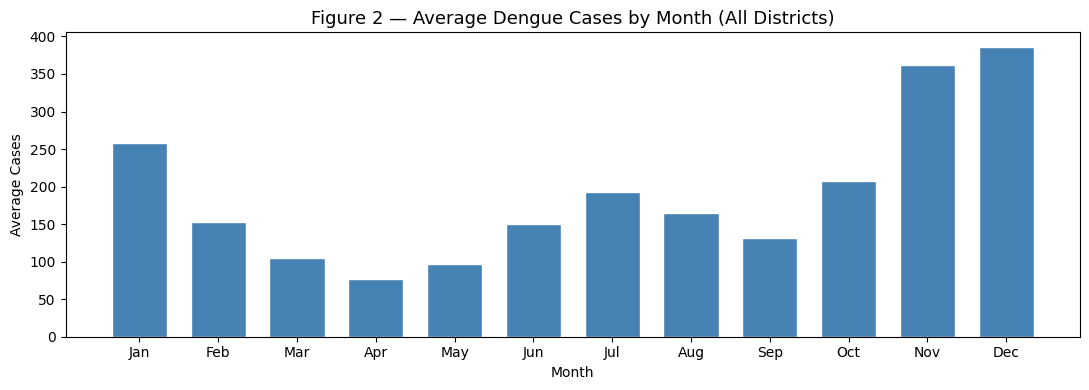

💾 Saved → plots/fig02_cases_by_month.png


In [5]:
# ── EDA Plot 2: Cases by Month ───────────────────────────────
monthly = df.groupby('Month')['Cases'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(11, 4))
bars = plt.bar(monthly.index, monthly.values, color='steelblue', edgecolor='white', width=0.7)
plt.xticks(range(1, 13), month_labels)
plt.title('Figure 2 — Average Dengue Cases by Month (All Districts)', fontsize=13)
plt.xlabel('Month'); plt.ylabel('Average Cases')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig02_cases_by_month.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig02_cases_by_month.png')

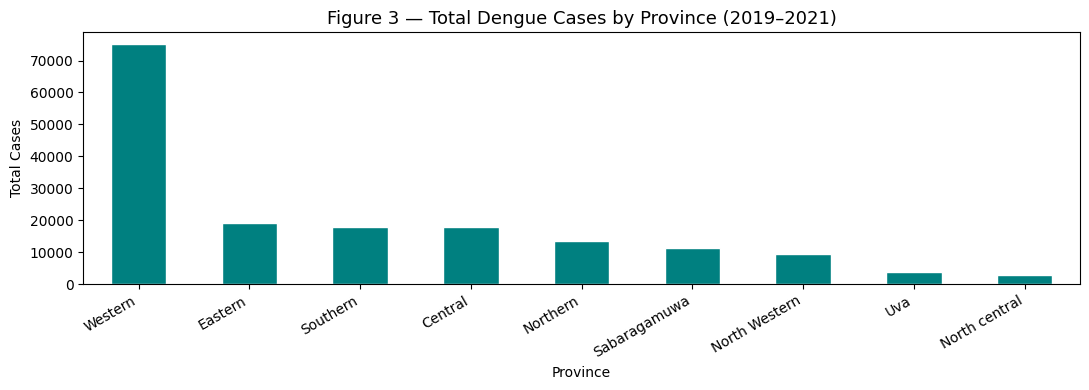

💾 Saved → plots/fig03_cases_by_province.png


In [6]:
# ── EDA Plot 3: Cases by Province ────────────────────────────
prov = df.groupby('Province')['Cases'].sum().sort_values(ascending=False)

plt.figure(figsize=(11, 4))
prov.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Figure 3 — Total Dengue Cases by Province (2019–2021)', fontsize=13)
plt.xlabel('Province'); plt.ylabel('Total Cases')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig03_cases_by_province.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig03_cases_by_province.png')

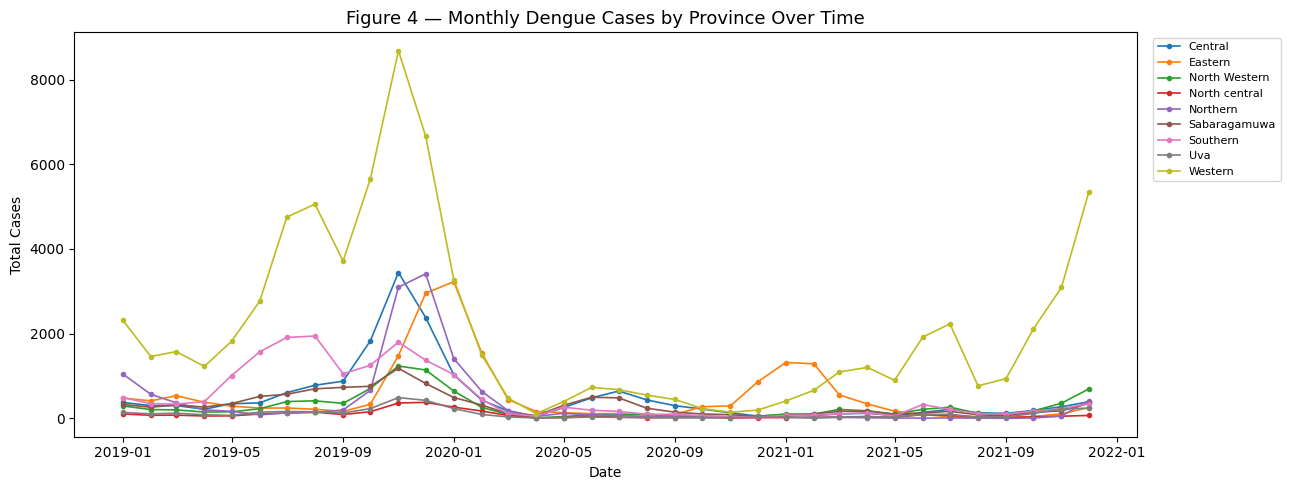

💾 Saved → plots/fig04_cases_over_time.png


In [7]:
# ── EDA Plot 4: Cases over Time per Province ─────────────────
time_prov = df.groupby(['Year', 'Month', 'Province'])['Cases'].sum().reset_index()
time_prov['Date'] = pd.to_datetime(
    time_prov['Year'].astype(str) + '-' + time_prov['Month'].astype(str) + '-01'
)

fig, ax = plt.subplots(figsize=(13, 5))
for prov_name, grp in time_prov.groupby('Province'):
    ax.plot(grp['Date'], grp['Cases'], marker='o', markersize=3, linewidth=1.2, label=prov_name)

ax.set_title('Figure 4 — Monthly Dengue Cases by Province Over Time', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Total Cases')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig04_cases_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig04_cases_over_time.png')

---
## 🧹 2. Data Preprocessing & Feature Engineering

In [8]:
# ── Fix Missing Values ────────────────────────────────────────
# Only 1 row has missing weather data → fill with column median
df['Temp_avg']          = df['Temp_avg'].fillna(df['Temp_avg'].median())
df['Precipitation_avg'] = df['Precipitation_avg'].fillna(df['Precipitation_avg'].median())
df['Humidity_avg']      = df['Humidity_avg'].fillna(df['Humidity_avg'].median())

print(f'Missing values after fix: {df.isnull().sum().sum()}')

Missing values after fix: 0


In [9]:
# ── Feature Engineering ───────────────────────────────────────

# 1. Season — Sri Lanka has two monsoon seasons
def get_season(month):
    if month in [5, 6, 7, 8, 9]:    return 'SouthwestMonsoon'
    elif month in [10, 11, 12, 1]:  return 'NortheastMonsoon'
    else:                            return 'InterMonsoon'

df['Season'] = df['Month'].apply(get_season)

# 2. Cyclical month encoding (month 12 and 1 should be close numerically)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# 3. Lag features — previous months' cases per district
#    Dengue spread is time-dependent: last month's cases predict this month's
df = df.sort_values(['District', 'Year', 'Month']).reset_index(drop=True)
df['Cases_lag1']     = df.groupby('District')['Cases'].shift(1)   # 1 month ago
df['Cases_lag2']     = df.groupby('District')['Cases'].shift(2)   # 2 months ago
df['Cases_rolling3'] = df.groupby('District')['Cases'].transform(
    lambda x: x.shift(1).rolling(3).mean()                         # 3-month rolling avg
)

print('New features added:')
print('  Season, Month_sin, Month_cos, Cases_lag1, Cases_lag2, Cases_rolling3')
print(f'\nDataset shape after feature engineering: {df.shape}')

New features added:
  Season, Month_sin, Month_cos, Cases_lag1, Cases_lag2, Cases_rolling3

Dataset shape after feature engineering: (900, 17)


In [10]:
# ── Encode Categorical Columns ────────────────────────────────
le_province = LabelEncoder()
le_district = LabelEncoder()
le_season   = LabelEncoder()

df['Province_enc'] = le_province.fit_transform(df['Province'])
df['District_enc'] = le_district.fit_transform(df['District'])
df['Season_enc']   = le_season.fit_transform(df['Season'])

print('Province encoding:', dict(zip(le_province.classes_,
                                     le_province.transform(le_province.classes_))))
print('\nDistrict encoding:', dict(zip(le_district.classes_,
                                      le_district.transform(le_district.classes_))))

Province encoding: {'Central': np.int64(0), 'Eastern': np.int64(1), 'North Western': np.int64(2), 'North central': np.int64(3), 'Northern': np.int64(4), 'Sabaragamuwa': np.int64(5), 'Southern': np.int64(6), 'Uva': np.int64(7), 'Western': np.int64(8)}

District encoding: {'Ampara': np.int64(0), 'Anuradhapura': np.int64(1), 'Badulla': np.int64(2), 'Batticaloa': np.int64(3), 'Colombo': np.int64(4), 'Galle': np.int64(5), 'Gampaha': np.int64(6), 'Hambantota': np.int64(7), 'Jaffna': np.int64(8), 'Kalutara': np.int64(9), 'Kandy': np.int64(10), 'Kegalle': np.int64(11), 'Kilinochchi': np.int64(12), 'Kurunegala': np.int64(13), 'Mannar': np.int64(14), 'Matale': np.int64(15), 'Matara': np.int64(16), 'Moneragala': np.int64(17), 'Mulativu': np.int64(18), 'Nuwara Eliya': np.int64(19), 'Polonnaruwa': np.int64(20), 'Puttalam': np.int64(21), 'Ratnapura': np.int64(22), 'Trincomalee': np.int64(23), 'Vavuniya': np.int64(24)}


In [11]:
# ── Drop rows with NaN lag values ─────────────────────────────
# The first 1-2 months per district have no lag history
df_model = df.dropna(subset=['Cases_lag1', 'Cases_lag2', 'Cases_rolling3']).copy()
print(f'Rows before lag drop : {len(df)}')
print(f'Rows after lag drop  : {len(df_model)}')

Rows before lag drop : 900
Rows after lag drop  : 825


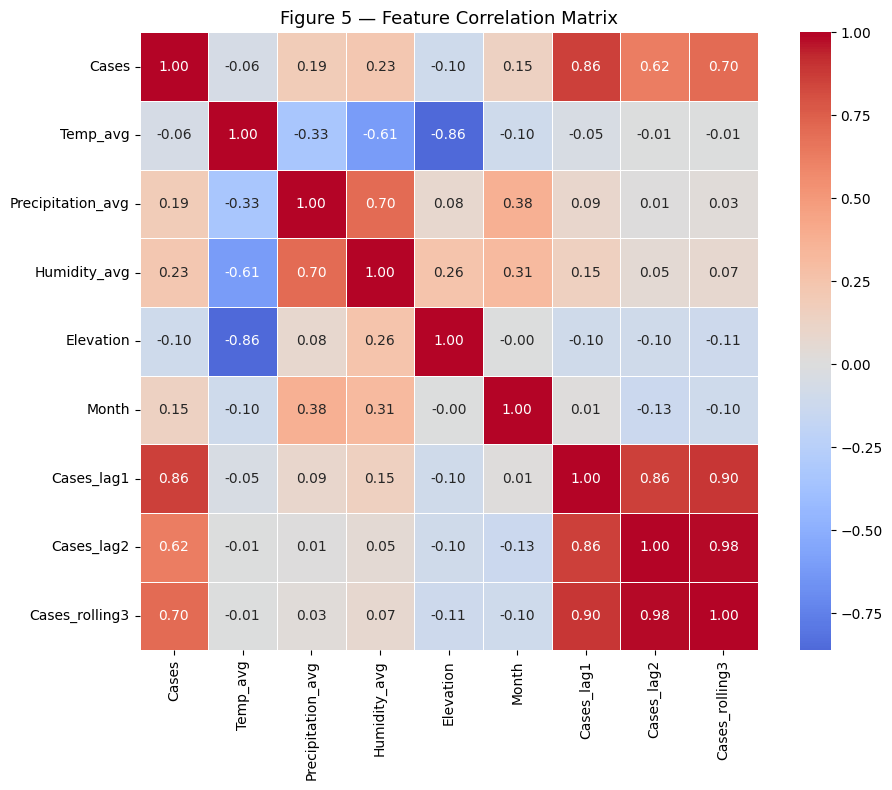

💾 Saved → plots/fig05_correlation_heatmap.png


In [12]:
# ── EDA Plot 5: Correlation Heatmap ──────────────────────────
num_cols = ['Cases', 'Temp_avg', 'Precipitation_avg', 'Humidity_avg',
            'Elevation', 'Month', 'Cases_lag1', 'Cases_lag2', 'Cases_rolling3']
corr = df_model[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Figure 5 — Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig05_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig05_correlation_heatmap.png')

In [13]:
# ── Save Cleaned Dataset ──────────────────────────────────────
df_model.to_csv(CLEANED_CSV, index=False)
print(f'✅ Cleaned dataset saved → {CLEANED_CSV}')
df_model.head()

✅ Cleaned dataset saved → d:\Education\Academic\ML Assignment\notebooks\..\data\Data_Cleaned.csv


,Year,Province,District,Latitude,Longitude,Elevation,Month,Cases,Temp_avg,Precipitation_avg,Humidity_avg,Season,Month_sin,Month_cos,Cases_lag1,Cases_lag2,Cases_rolling3,Province_enc,District_enc,Season_enc
3,2019,Eastern,Ampara,7.275923,81.693474,38,4,104,28.900000,1.764286,78.928571,InterMonsoon,8.660254e-01,-0.500000,152.0,112.0,132.000000,1,0,0
4,2019,Eastern,Ampara,7.275923,81.693474,38,5,78,30.760714,0.803571,68.321429,SouthwestMonsoon,5.000000e-01,-0.866025,104.0,152.0,122.666667,1,0,2
5,2019,Eastern,Ampara,7.275923,81.693474,38,6,72,31.714286,1.892857,62.892857,SouthwestMonsoon,1.224647e-16,-1.000000,78.0,104.0,111.333333,1,0,2
6,2019,Eastern,Ampara,7.275923,81.693474,38,7,55,31.458929,1.535714,62.035714,SouthwestMonsoon,-5.000000e-01,-0.866025,72.0,78.0,84.666667,1,0,2
7,2019,Eastern,Ampara,7.275923,81.693474,38,8,66,30.628571,2.264286,66.500000,SouthwestMonsoon,-8.660254e-01,-0.500000,55.0,72.0,68.333333,1,0,2


---
## 🤖 3. Algorithm Selection — XGBoost

### Why XGBoost?

XGBoost (eXtreme Gradient Boosting) was selected as the primary model for this assignment. It was **not covered in lectures** (which covered decision trees, logistic regression, kNN, and basic random forests).

**How XGBoost differs from standard models:**

| Property | Decision Tree | Random Forest | XGBoost |
|----------|--------------|---------------|---------|
| Training | Single tree | Parallel trees | Sequential trees (each corrects previous) |
| Regularization | ❌ None | ❌ None | ✅ L1 + L2 |
| Overfitting control | ❌ Prone | Moderate | ✅ Strong |
| Speed | Fast | Slow | Fast (parallelized splits) |
| SHAP integration | Partial | Partial | ✅ Native |

**Key idea:** XGBoost builds trees *sequentially*. Each new tree learns from the *residual errors* of all previous trees, progressively reducing prediction error. This is called **gradient boosting**.

**Justification for this dataset:**
- Handles mixed feature types (numeric + encoded categorical)
- Built-in regularization prevents overfitting on ~850 rows
- Early stopping automatically selects the optimal number of trees
- Native SHAP support for XAI requirements

---
## 🏋️ 4. Model Training & Evaluation

In [14]:
# ── Define Features & Target ──────────────────────────────────
FEATURES = [
    'Year', 'Month_sin', 'Month_cos',              # time (cyclical encoding)
    'Latitude', 'Longitude', 'Elevation',           # geography
    'Temp_avg', 'Precipitation_avg', 'Humidity_avg',# weather
    'Province_enc', 'District_enc', 'Season_enc',   # encoded categoricals
    'Cases_lag1', 'Cases_lag2', 'Cases_rolling3'    # lag features
]
TARGET = 'Cases'

X = df_model[FEATURES]
y = df_model[TARGET]

# ── Time-Aware Split ──────────────────────────────────────────
# Train: 2019–2020 | Test: 2021
# This avoids data leakage — model cannot see future years during training
train_val = df_model[df_model['Year'] != 2021]
test      = df_model[df_model['Year'] == 2021]

X_train_val = train_val[FEATURES]; y_train_val = train_val[TARGET]
X_test      = test[FEATURES];      y_test      = test[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=42
)

print('Data Split (time-aware):')
print(f'  Train      : {len(X_train):>4} samples  (2019–2020, 80%)')
print(f'  Validation : {len(X_val):>4} samples  (2019–2020, 20%)')
print(f'  Test       : {len(X_test):>4} samples  (2021 — held-out year)')

# Baseline: always predict the training mean
baseline_mae = mean_absolute_error(y_test, np.full(len(y_test), y_train.mean()))
print(f'\nBaseline MAE (predict mean): {baseline_mae:.2f}')

Data Split (time-aware):
  Train      :  420 samples  (2019–2020, 80%)
  Validation :  105 samples  (2019–2020, 20%)
  Test       :  300 samples  (2021 — held-out year)

Baseline MAE (predict mean): 224.24


In [15]:
# ── Step 1: Train with Early Stopping to find best n_estimators ─
early_model = XGBRegressor(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 5,
    min_child_weight      = 3,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.5,
    objective             = 'reg:squarederror',
    random_state          = 42,
    early_stopping_rounds = 30
)
early_model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_val, y_val)],
    verbose  = 50
)
best_round = early_model.best_iteration
print(f'\n✅ Best n_estimators (early stopping): {best_round}')

[0]	validation_0-rmse:464.87262	validation_1-rmse:427.61408
[50]	validation_0-rmse:124.47559	validation_1-rmse:213.45941
[62]	validation_0-rmse:104.34348	validation_1-rmse:225.18460

✅ Best n_estimators (early stopping): 32


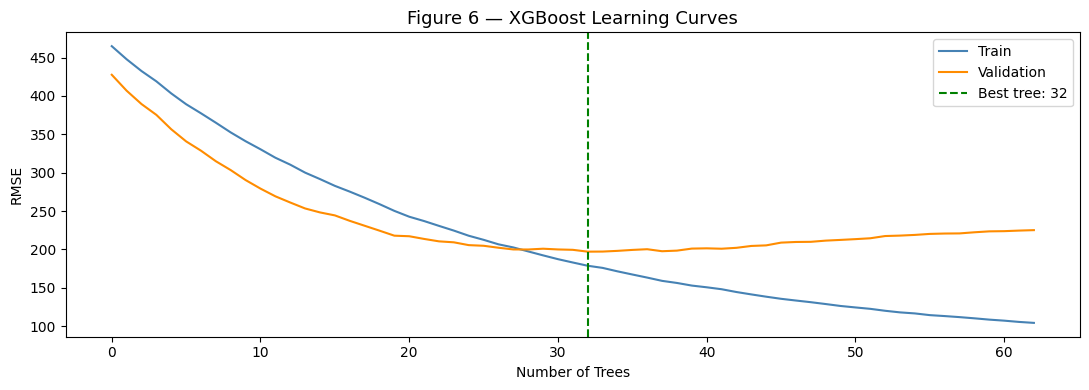

💾 Saved → plots/fig06_learning_curves.png


In [16]:
# ── Plot 6: Learning Curves ───────────────────────────────────
results = early_model.evals_result()
epochs  = len(results['validation_0']['rmse'])

plt.figure(figsize=(11, 4))
plt.plot(range(epochs), results['validation_0']['rmse'], label='Train',      color='steelblue')
plt.plot(range(epochs), results['validation_1']['rmse'], label='Validation', color='darkorange')
plt.axvline(best_round, color='green', linestyle='--', label=f'Best tree: {best_round}')
plt.xlabel('Number of Trees'); plt.ylabel('RMSE')
plt.title(f'Figure 6 — XGBoost Learning Curves', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig06_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig06_learning_curves.png')

In [17]:
# ── Step 2: Hyperparameter Tuning with GridSearchCV ───────────
param_grid = {
    'max_depth'        : [4, 5, 6],
    'learning_rate'    : [0.03, 0.05, 0.1],
    'min_child_weight' : [1, 3, 5],
}
grid_search = GridSearchCV(
    XGBRegressor(
        n_estimators=best_round, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.5, objective='reg:squarederror', random_state=42
    ),
    param_grid,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_val, y_train_val)
best_params = grid_search.best_params_

print(f'\n✅ Best hyperparameters : {best_params}')
print(f'   Best CV MAE         : {-grid_search.best_score_:.2f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Best hyperparameters : {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 3}
   Best CV MAE         : 88.60


In [18]:
# ── Step 3: Train Final Model with Best Hyperparameters ───────
final_model = XGBRegressor(
    n_estimators     = best_round,
    learning_rate    = best_params['learning_rate'],
    max_depth        = best_params['max_depth'],
    min_child_weight = best_params['min_child_weight'],
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.5,
    objective        = 'reg:squarederror',
    random_state     = 42
)
final_model.fit(X_train_val, y_train_val)
print('✅ Final model trained on full 2019–2020 data')

✅ Final model trained on full 2019–2020 data


In [19]:
# ── Evaluate on 2021 Test Set ─────────────────────────────────
y_pred = np.maximum(final_model.predict(X_test), 0)   # no negative case counts

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

cv_scores   = cross_val_score(final_model, X, y, cv=5,
                               scoring='neg_mean_absolute_error', n_jobs=-1)
improvement = ((baseline_mae - mae) / baseline_mae) * 100

print('=' * 50)
print('EVALUATION RESULTS (Test Set — Year 2021)')
print('=' * 50)
results_df = pd.DataFrame({
    'Metric': ['Baseline MAE', 'XGBoost MAE', 'XGBoost RMSE',
               'XGBoost R²', '5-Fold CV MAE', 'Improvement vs Baseline'],
    'Value':  [f'{baseline_mae:.2f}', f'{mae:.2f}', f'{rmse:.2f}',
               f'{r2:.4f}', f'{-cv_scores.mean():.2f} ± {cv_scores.std():.2f}',
               f'{improvement:.1f}%']
})
print(results_df.to_string(index=False))

EVALUATION RESULTS (Test Set — Year 2021)
                 Metric         Value
           Baseline MAE        224.24
            XGBoost MAE         55.44
           XGBoost RMSE        132.04
             XGBoost R²        0.7811
          5-Fold CV MAE 75.38 ± 34.45
Improvement vs Baseline         75.3%


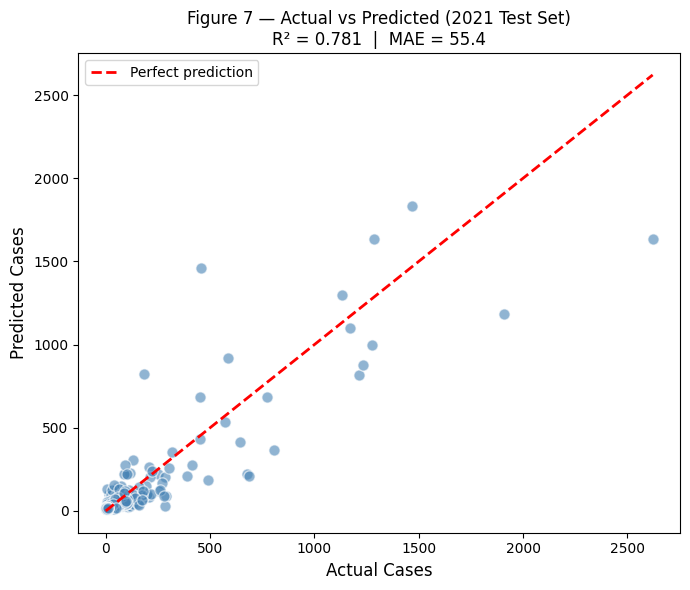

💾 Saved → plots/fig07_actual_vs_predicted.png


In [20]:
# ── Plot 7: Actual vs Predicted ───────────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', s=65)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Cases', fontsize=12)
plt.ylabel('Predicted Cases', fontsize=12)
plt.title(f'Figure 7 — Actual vs Predicted (2021 Test Set)\nR² = {r2:.3f}  |  MAE = {mae:.1f}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig07_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig07_actual_vs_predicted.png')

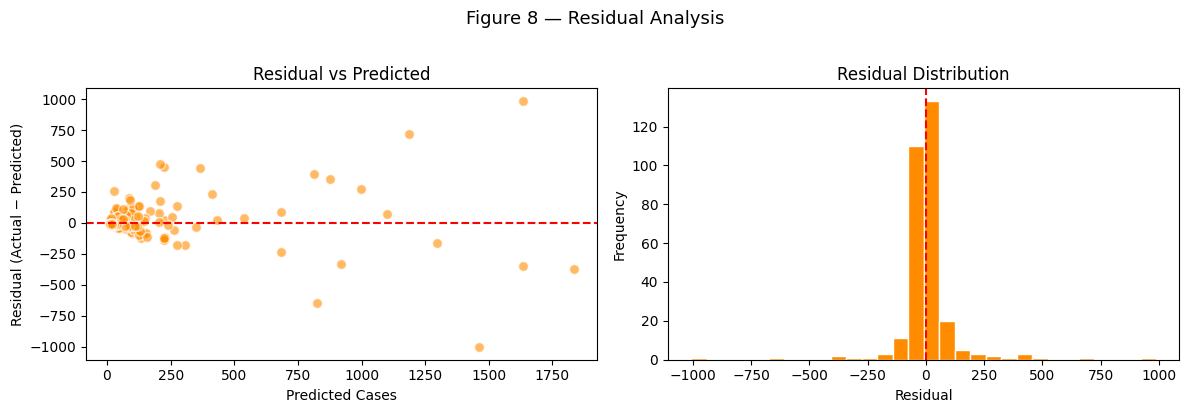

💾 Saved → plots/fig08_residuals.png


In [21]:
# ── Plot 8: Residuals ─────────────────────────────────────────
residuals = y_test.values - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='white', s=50)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Cases'); axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residual vs Predicted')

axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('Figure 8 — Residual Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig08_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig08_residuals.png')

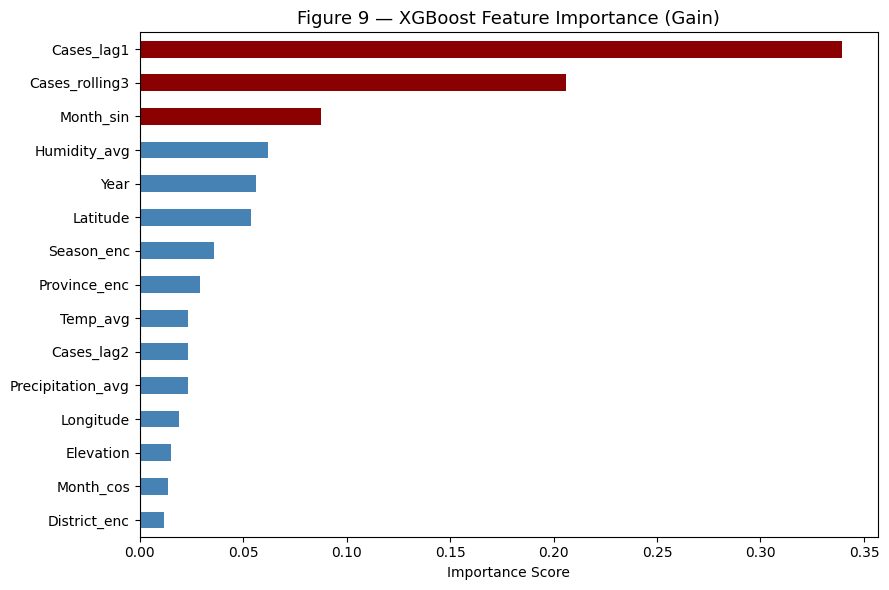

💾 Saved → plots/fig09_feature_importance.png


In [22]:
# ── Plot 9: XGBoost Built-in Feature Importance ───────────────
feat_imp = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors   = ['darkred' if i >= len(feat_imp) - 3 else 'steelblue'
            for i in range(len(feat_imp))]

plt.figure(figsize=(9, 6))
feat_imp.plot(kind='barh', color=colors)
plt.title('Figure 9 — XGBoost Feature Importance (Gain)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig09_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig09_feature_importance.png')

In [23]:
# ── Save Model → models/xgb_model.pkl ────────────────────────
with open(MODEL_PKL, 'wb') as f:
    pickle.dump({
        'model'       : final_model,
        'features'    : FEATURES,
        'best_round'  : best_round,
        'best_params' : best_params
    }, f)
print(f'✅ Model saved → {MODEL_PKL}')

✅ Model saved → d:\Education\Academic\ML Assignment\notebooks\..\models\xgb_model.pkl


---
##  5. Explainability with SHAP

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution score for every individual prediction, based on Shapley values from cooperative game theory. Unlike simple feature importance which gives a global rank, SHAP shows:
- The **direction** of each feature's effect (positive = increases cases, negative = decreases cases)
- The **magnitude** of that effect in actual case units
- A full explanation for **every individual prediction**

In [24]:
# ── Compute SHAP Values ───────────────────────────────────────
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape    : {shap_values.shape}')
print(f'Model baseline value : {explainer.expected_value:.2f} cases')
print('(Baseline = average prediction if we knew nothing about the sample)')

SHAP values shape    : (300, 15)
Model baseline value : 230.54 cases
(Baseline = average prediction if we knew nothing about the sample)


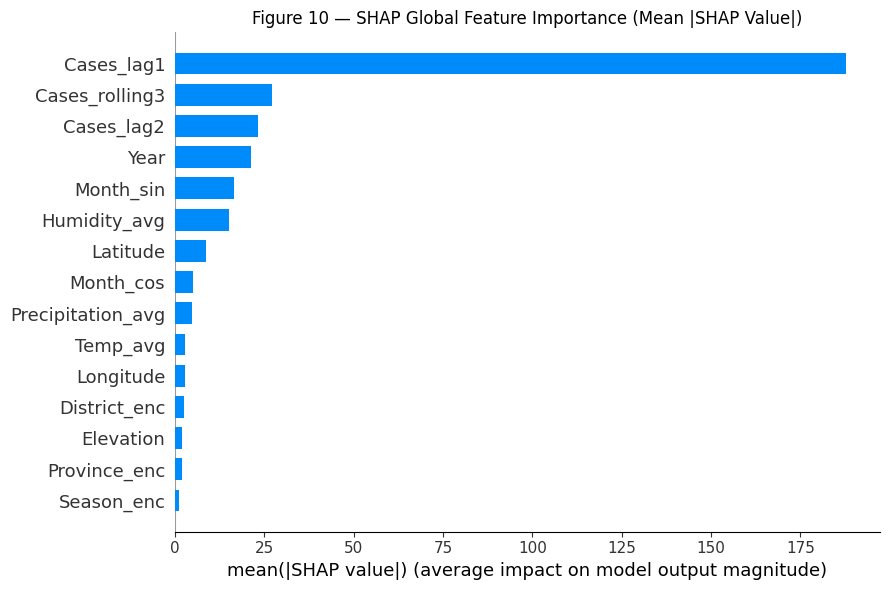

💾 Saved → plots/fig10_shap_bar.png


In [25]:
# ── Plot 10: SHAP Summary Bar — Global Feature Importance ─────
# Shows mean |SHAP value| per feature — which features matter most overall
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar', feature_names=FEATURES,
    show=False, plot_size=None
)
plt.title('Figure 10 — SHAP Global Feature Importance (Mean |SHAP Value|)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig10_shap_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig10_shap_bar.png')

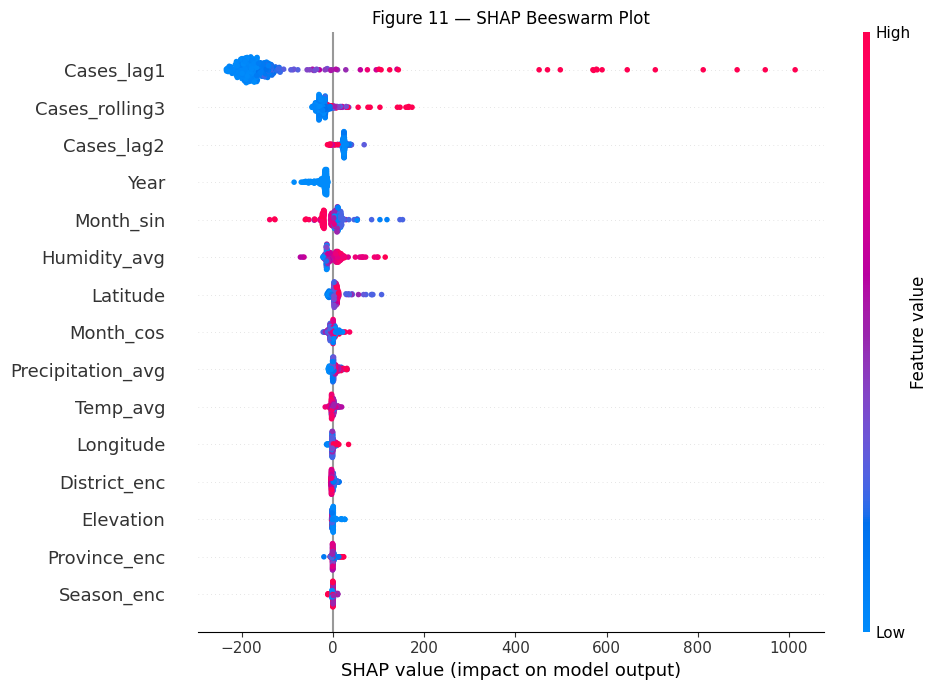

💾 Saved → plots/fig11_shap_beeswarm.png


In [26]:
# ── Plot 11: SHAP Beeswarm — Direction & Magnitude ────────────
# Red = high feature value, Blue = low feature value
# X-axis = SHAP value = how much that feature pushed the prediction
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURES,
    show=False, plot_size=None
)
plt.title('Figure 11 — SHAP Beeswarm Plot', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig11_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig11_shap_beeswarm.png')

Explaining: Colombo, Month 12
  Actual    : 2621 cases
  Predicted : 1633 cases


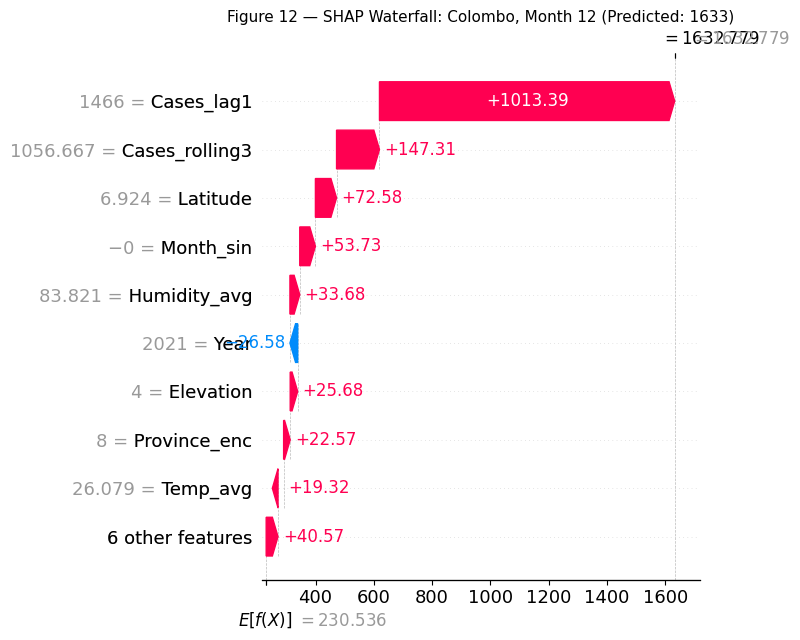

💾 Saved → plots/fig12_shap_waterfall.png


In [27]:
# ── Plot 12: SHAP Waterfall — Explain One Prediction ─────────
# Pick the district-month with the highest actual case count
worst_idx  = y_test.values.argmax()
sample_X   = X_test.iloc[[worst_idx]]
pred_cases = final_model.predict(sample_X)[0]
actual     = y_test.values[worst_idx]

print(f'Explaining: {test["District"].values[worst_idx]}, '
      f'Month {test["Month"].values[worst_idx]}')
print(f'  Actual    : {actual:.0f} cases')
print(f'  Predicted : {pred_cases:.0f} cases')

explanation = shap.Explanation(
    values        = shap_values[worst_idx],
    base_values   = explainer.expected_value,
    data          = sample_X.values[0],
    feature_names = FEATURES
)
plt.figure(figsize=(11, 7))
shap.waterfall_plot(explanation, show=False)
plt.title(
    f'Figure 12 — SHAP Waterfall: {test["District"].values[worst_idx]}, '
    f'Month {test["Month"].values[worst_idx]} (Predicted: {pred_cases:.0f})',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig12_shap_waterfall.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig12_shap_waterfall.png')

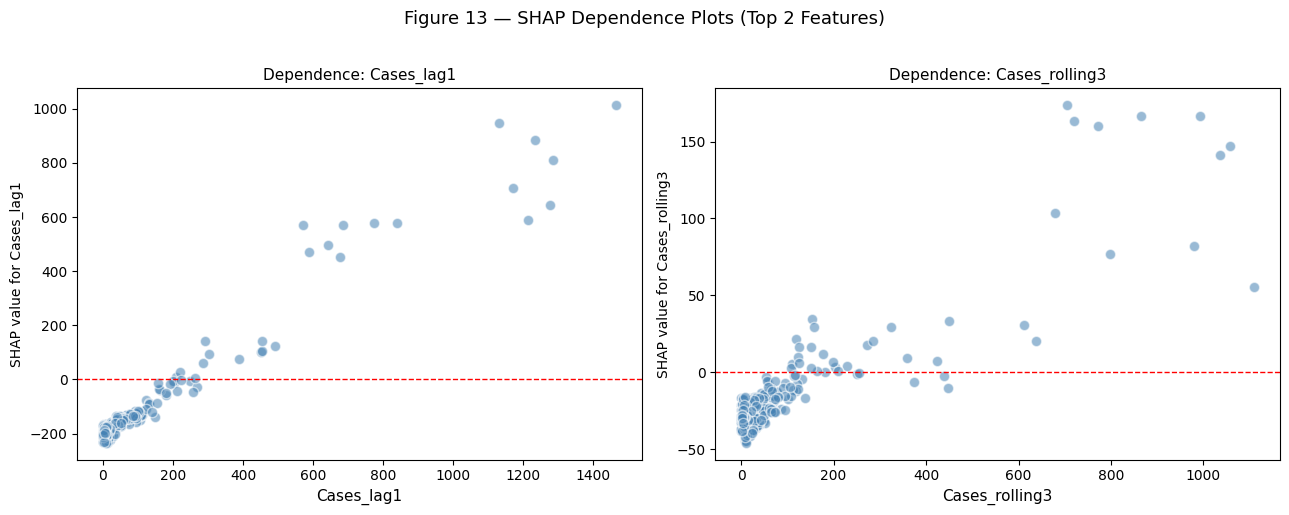

💾 Saved → plots/fig13_shap_dependence.png


In [28]:
# ── Plot 13: SHAP Dependence — Top 2 Features ────────────────
# Shows how a feature's value relates to its SHAP impact
mean_abs   = np.abs(shap_values).mean(axis=0)
top2_idx   = np.argsort(mean_abs)[::-1][:2]
top2_feats = [FEATURES[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2_feats):
    fidx = FEATURES.index(feat)
    ax.scatter(X_test[feat], shap_values[:, fidx],
               alpha=0.55, color='steelblue', edgecolors='white', s=55)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel(f'SHAP value for {feat}', fontsize=10)
    ax.set_title(f'Dependence: {feat}', fontsize=11)

plt.suptitle('Figure 13 — SHAP Dependence Plots (Top 2 Features)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'fig13_shap_dependence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved → plots/fig13_shap_dependence.png')

In [29]:
# ── SHAP Insights for Report ──────────────────────────────────
shap_df   = pd.DataFrame(shap_values, columns=FEATURES)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

print('Top 5 most influential features (SHAP):')
print('-' * 55)
for rank, (feat, val) in enumerate(mean_shap.head(5).items(), 1):
    direction = '↑ increases' if shap_df[feat].mean() > 0 else '↓ decreases'
    print(f'  {rank}. {feat:<25} mean |SHAP| = {val:.2f}  ({direction} cases)')

precip_hi  = shap_df.loc[X_test['Precipitation_avg'].values > X_test['Precipitation_avg'].median(),
                          'Precipitation_avg'].mean()
precip_lo  = shap_df.loc[X_test['Precipitation_avg'].values <= X_test['Precipitation_avg'].median(),
                          'Precipitation_avg'].mean()
print(f'\nPrecipitation effect:')
print(f'  High rainfall SHAP = {precip_hi:+.2f}  (more rain → more cases)')
print(f'  Low  rainfall SHAP = {precip_lo:+.2f}  (less rain → fewer cases)')
print('  ✅ Aligns with domain knowledge: stagnant water = mosquito breeding')

Top 5 most influential features (SHAP):
-------------------------------------------------------
  1. Cases_lag1                mean |SHAP| = 187.91  (↓ decreases cases)
  2. Cases_rolling3            mean |SHAP| = 27.21  (↓ decreases cases)
  3. Cases_lag2                mean |SHAP| = 23.35  (↑ increases cases)
  4. Year                      mean |SHAP| = 21.24  (↓ decreases cases)
  5. Month_sin                 mean |SHAP| = 16.54  (↑ increases cases)

Precipitation effect:
  High rainfall SHAP = +6.53  (more rain → more cases)
  Low  rainfall SHAP = -1.53  (less rain → fewer cases)
  ✅ Aligns with domain knowledge: stagnant water = mosquito breeding
